# REsults analysis 2 - Trying out random rec, most popular rec and classical bpr with L = 40_000

Changes to previous version: Essentially tries baselines for longer, and also removes previously interacted items. Includes bpr without debiasing.

In [1]:
from dynamicTasteDistortion.scripts.vis import plot_metric_comparison
from dynamicTasteDistortion.scripts.vis import plot_metrics_smoothed

### Experiments files

In [ ]:
bpr_exp = "experiments/bpr_classic_big_one.yaml"
bpr_unbiased = "experiments/bpr_with_oracle_experiment_big_one.yaml"
most_popular = "experiments/most_popular_with_oracle_big_one.yaml"
random_rec = "experiments/random_rec_with_oracle_big_one.yaml"

## Data visualization

In [13]:
from dynamicTasteDistortion.ioUtils import read_experiment, read_metrics
bpr_unbiased_exp = read_experiment(bpr_unbiased)
mace, kl = read_metrics(bpr_unbiased_exp)

In [14]:
bpr_biased_exp = read_experiment(bpr_exp)
mace_biased, kl_biased = read_metrics(bpr_biased_exp)

In [17]:
from dynamicTasteDistortion.scripts.metrics_utils import remove_outliers

In [18]:
mace_outliers_removed = remove_outliers(mace_biased)

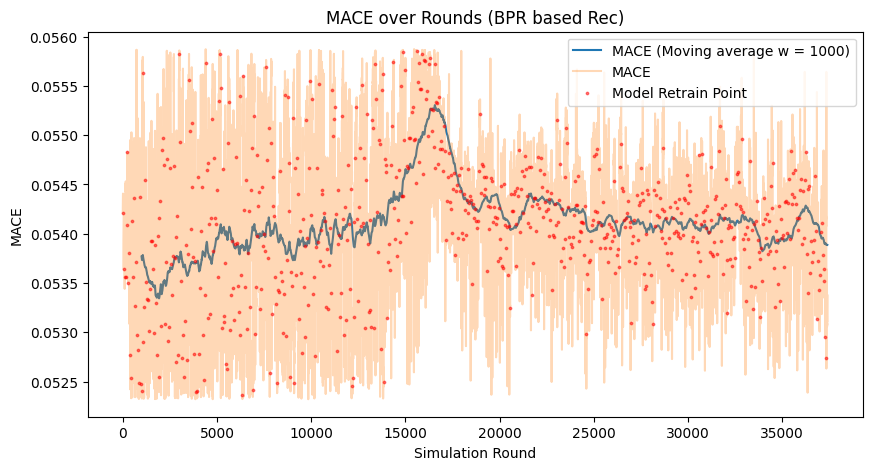

In [19]:
# Versão removendo itens do histórico antes de recomendar.
plot_metrics_smoothed(ax=None, metric=mace_outliers_removed, model_name="BPR", metric_name="MACE", step=bpr_biased_exp["num_rounds_per_eval"], window_size=1000)

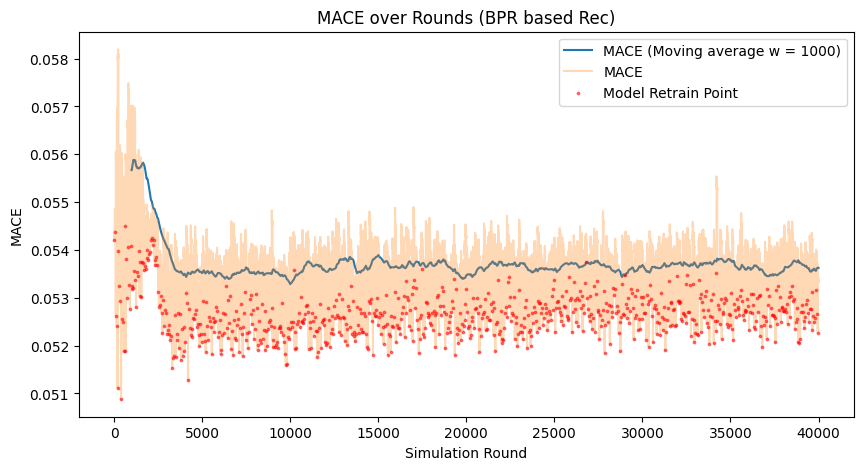

In [16]:
# Versão removendo itens do histórico antes de recomendar.
plot_metrics_smoothed(ax=None, metric=mace, model_name="BPR", metric_name="MACE", step=bpr_unbiased_exp["num_rounds_per_eval"], window_size=1000)

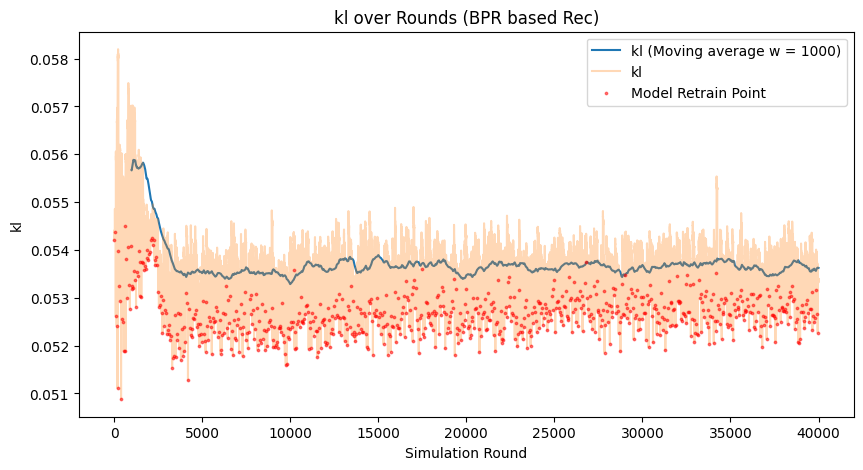

In [10]:
# Versão removendo itens do histórico antes de recomendar.
plot_metrics_smoothed(ax=None, metric=mace, model_name="BPR", metric_name="kl", step=bpr_unbiased_exp["num_rounds_per_eval"], window_size=1000)

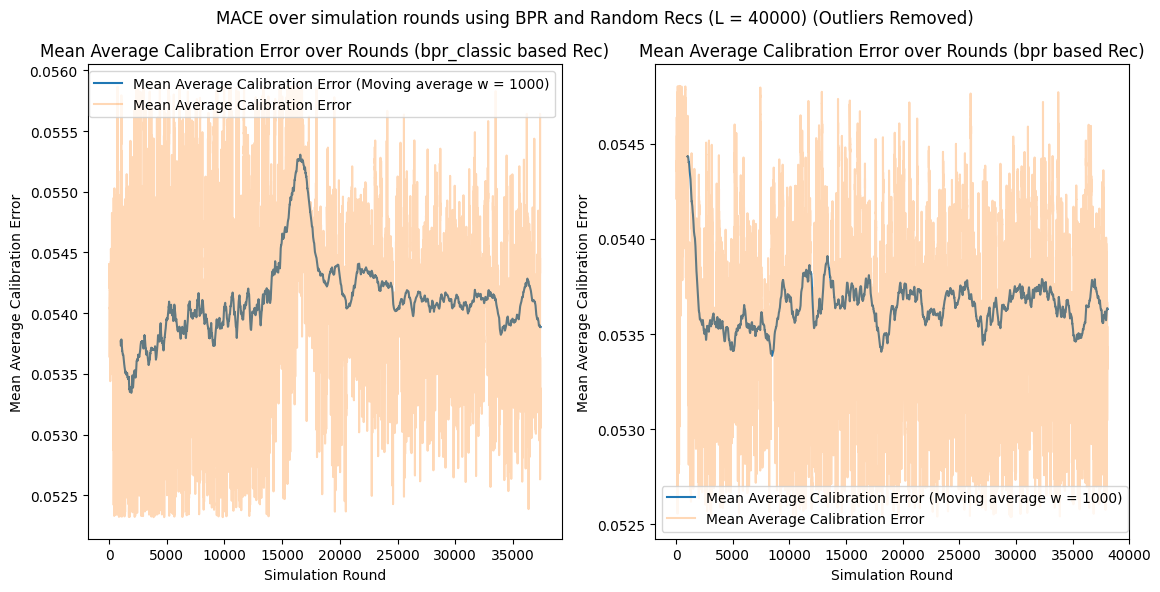

In [11]:
plot_metric_comparison(bpr_exp, bpr_unbiased, metric_name="mace", title="MACE over simulation rounds using BPR and Random Recs (L = 40000)", graph="line", plot_retrain_points=False,  window_size=1000, should_remove_outliers=True)

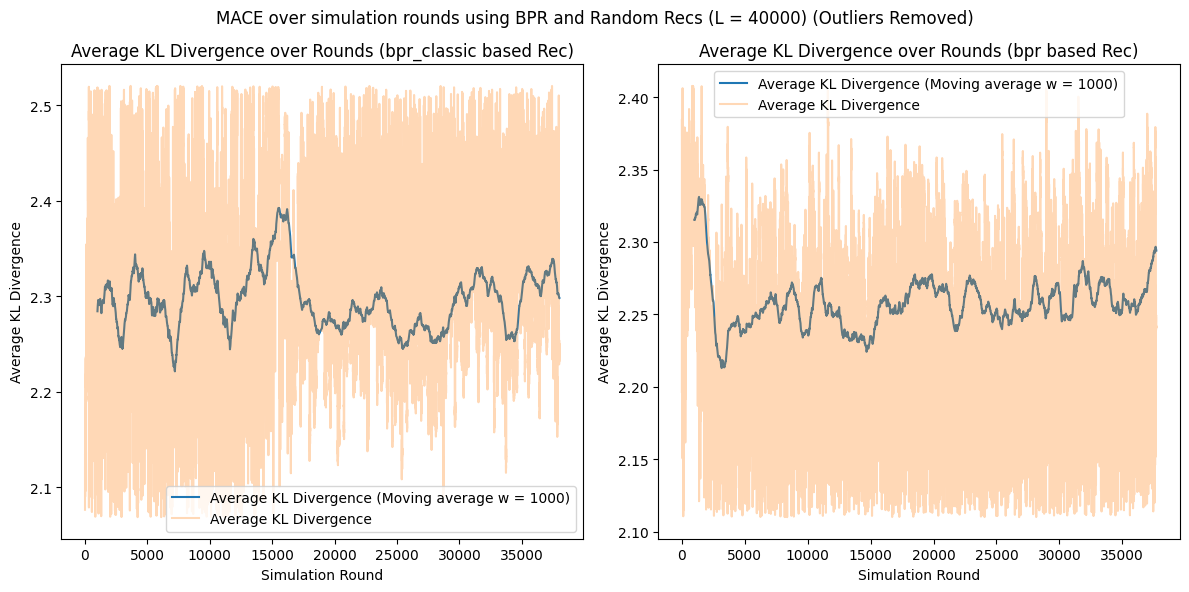

In [4]:
plot_metric_comparison(bpr_exp, bpr_unbiased, metric_name="kl", title="MACE over simulation rounds using BPR and Random Recs (L = 40000)", graph="line", plot_retrain_points=False,  window_size=1000, should_remove_outliers=True)

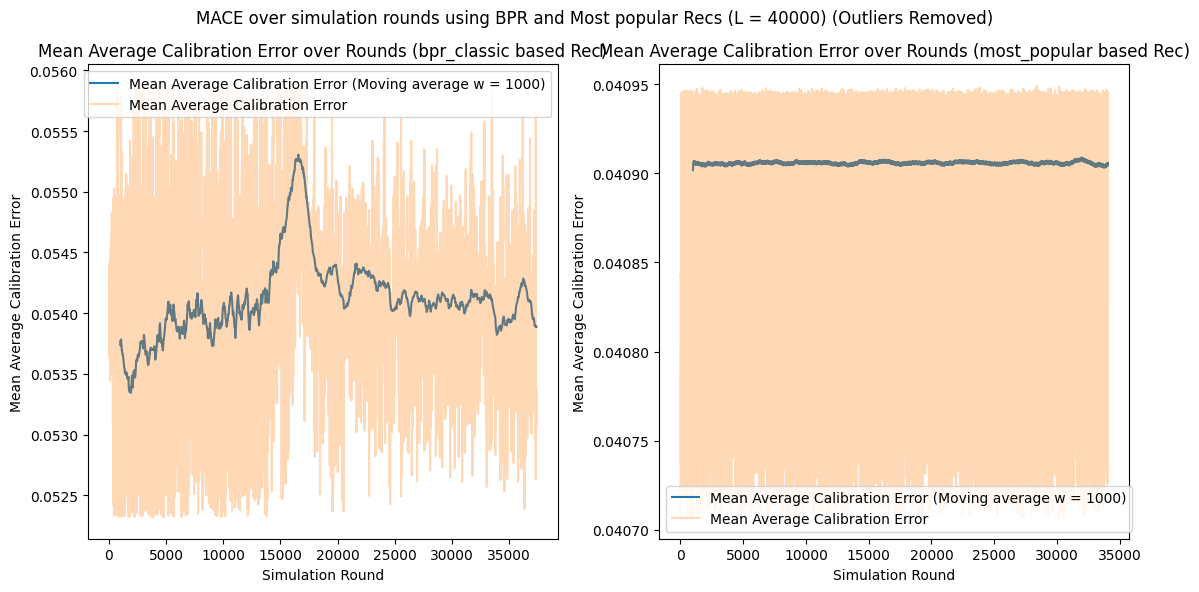

In [5]:
plot_metric_comparison(bpr_exp, most_popular, metric_name="mace", title="MACE over simulation rounds using BPR and Most popular Recs (L = 40000)", graph="line", plot_retrain_points=False,  window_size=1000, should_remove_outliers=True)